## 🤖 AI Worker Burnout & Attrition Risk — 2026 ##
As AI tools become deeply embedded in tech workflows, a new workplace
crisis is emerging: AI-induced burnout. Tech workers are using more AI
tools than ever — but at what cost to their mental health, job
satisfaction, and career longevity? 

This dataset captures the intersection of AI tool adoption and
employee wellbeing across 1,500 tech professionals globally in 2026.

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3 
df = pd.read_csv('C:/Users/Fatima zahra/OneDrive/Desktop/MyProjects/ai_worker_burnout_attrition_2026/ai_worker_burnout_attrition_2026.csv')
conn = sqlite3.connect('ai_worker_burnout.db')
df.to_sql('ai_worker_burnout', conn, if_exists='replace', index = False)

## print(df.columns.to_list())

df.isnull().sum()


employee_id                       0
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64

## The over view data looks fine ##

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object

In [8]:
df.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


# 🤖 AI in the Workplace — Who Thrives and Who Burns Out?

**Author:** Fatima Zahra Boutkhil
**Tools:** Python (Pandas, Matplotlib, Seaborn) + SQL (SQLite)
**Data:** AI Worker Burnout & Attrition Dataset (Kaggle)

---

## Introduction

Artificial Intelligence is reshaping every industry — but what is it 
doing to the people behind the screens?

This project explores the human side of the AI revolution.
Not the tools, not the models — but the workers navigating a world 
where their skills, their jobs, and their mental health are all 
being challenged at once.

As a self-taught analyst learning in this exact environment,
these questions feel personal. The data might have answers 
that surprise us both.

---

## Questions I'll Answer

1. Which jobs are most at risk of disappearing with AI?
2. Do highly educated people worry less about AI replacement?
3. Do self-taught employees have worse mental health?
4. Does higher AI tool usage increase productivity or burnout — or both?
5. Do remote workers experience different burnout patterns?
6. Do higher salaries protect against burnout?
7. Which country has the highest attrition risk?
8. Is there a relationship between burnout and job satisfaction?
9. Is there a sweet spot of AI usage that maximizes productivity 
   without burnout?

---
*Analysis by Fatima Zahra Boutkhil | Data: Kaggle*


## 1. Which jobs are most at risk of disappearing with AI? ##

In [55]:
risks = df.groupby('job_role').agg(
    avg_replaces_tasks=('ai_replaces_my_tasks_pct', 'median'),
    avg_ai_tools=('ai_tools_used_per_day', 'median'),
    avg_hours_ai=('hours_with_ai_assistance_daily', 'mean'),
).round(2)

print(risks.sort_values('avg_replaces_tasks', ascending=False))



                   avg_replaces_tasks  avg_ai_tools  avg_hours_ai
job_role                                                         
Backend Engineer                 44.0           4.0          4.30
Data Scientist                   43.0           4.0          3.96
DevOps Engineer                  42.5           4.0          4.00
ML Engineer                      42.0           5.0          4.59
Cloud Architect                  41.0           4.0          4.35
Data Analyst                     41.0           4.0          4.08
Frontend Engineer                41.0           4.0          4.12
Software Engineer                41.0           4.0          4.19
AI Ethics Officer                39.5           4.0          4.47
Product Manager                  37.0           4.0          4.17
AI Researcher                    35.0           4.0          4.13
Prompt Engineer                  33.0           5.0          4.52


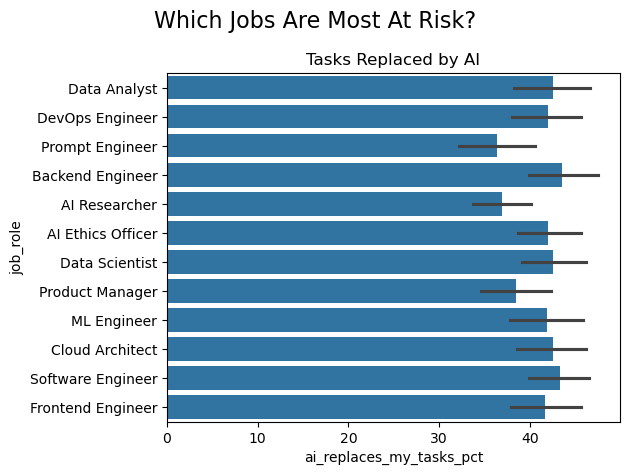

In [68]:
sns.barplot(data=df, x='ai_replaces_my_tasks_pct', y='job_role').set_title('Tasks Replaced by AI')

plt.suptitle('Which Jobs Are Most At Risk?', fontsize=16)
plt.tight_layout()
plt.show()

### 💡 Key Insights — Which Jobs Are Most At Risk?

**Backend Engineers** have the highest task replacement rate — 
over 40% of their daily tasks are already being handled by AI.
Their role is quietly being automated from the inside.

**Prompt Engineers and ML Engineers** spend the most time working 
alongside AI — up to 5 hours daily. They're not being replaced yet, 
but they are the most AI-dependent roles in the workforce.

**AI Ethics Officers** tell the most paradoxical story —
despite working in AI themselves, they report the highest fear 
of replacement and the highest attrition risk.
The people hired to make AI safe don't feel safe themselves.

> *"The most at-risk jobs aren't always the ones you'd expect.
> Sometimes the people closest to AI are the ones who fear it most."*

## 2. Do highly educated people worry less about AI replacement?

In [41]:
print(df['education_level'].unique())

['PhD' 'Self-taught' 'Master' 'Bachelor' 'Bootcamp']


In [54]:
fear_counts = df.groupby(['education_level', 'fear_of_ai_replacement']).size().unstack(fill_value=0)
print(fear_counts)

fear_of_ai_replacement  High  Low  Medium
education_level                          
Bachelor                  77  106     131
Bootcamp                  58  100     126
Master                    76  109     138
PhD                       78  110     106
Self-taught               69   98     118


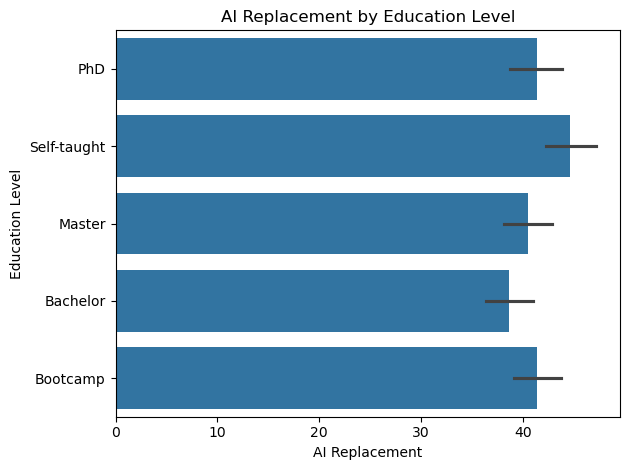

In [53]:
sns.barplot(data=df, x='ai_replaces_my_tasks_pct', y='education_level')
plt.title('AI Replacement by Education Level')
plt.ylabel('Education Level')
plt.xlabel('AI Replacement')
plt.tight_layout()
plt.show()

### 💡 What did we find?

Education level has no significant relationship with AI replacement 
or fear of AI.

Whether self-taught, bootcamp, Bachelor's, Master's, or PhD — 
the numbers tell the same story across the board.

This challenges a common assumption: that more formal education 
protects you from AI disruption.

The data suggests something more interesting:
**It's not about how you learned — it's about what you do with it.**
A self-taught developer and a PhD researcher face the same AI reality.
The path to your skills doesn't determine your risk.
Your adaptability does.

## 3. Do self-taught employees have worse mental health?

In [59]:
risks3 = df.groupby('education_level').agg(
    avg_burnout=('burnout_score', 'mean')
).round(2)

print(risks3.sort_values('avg_burnout', ascending=False))


                 avg_burnout
education_level             
Self-taught            51.85
Master                 50.03
Bootcamp               49.99
PhD                    49.88
Bachelor               48.68


### 💡 What did we find?
Self-taught employees have the highest average burnout at 51.85 — 
but the difference across all education levels is minimal.

From Bachelor (48.68) to Self-taught (51.85) — everyone is burning out.

The real story isn't about education level at all.
Burnout in the AI workplace appears to be universal —
no degree protects you from exhaustion.

## 4. Does higher AI tool usage increase productivity or burnout — or both?

In [60]:
corr_productivity = df['ai_tools_used_per_day'].corr(df['productivity_score'])
corr_burnout = df['ai_tools_used_per_day'].corr(df['burnout_score'])

print(f"AI tools vs Productivity: {corr_productivity:.2f}")
print(f"AI tools vs Burnout: {corr_burnout:.2f}")

AI tools vs Productivity: 0.31
AI tools vs Burnout: -0.00


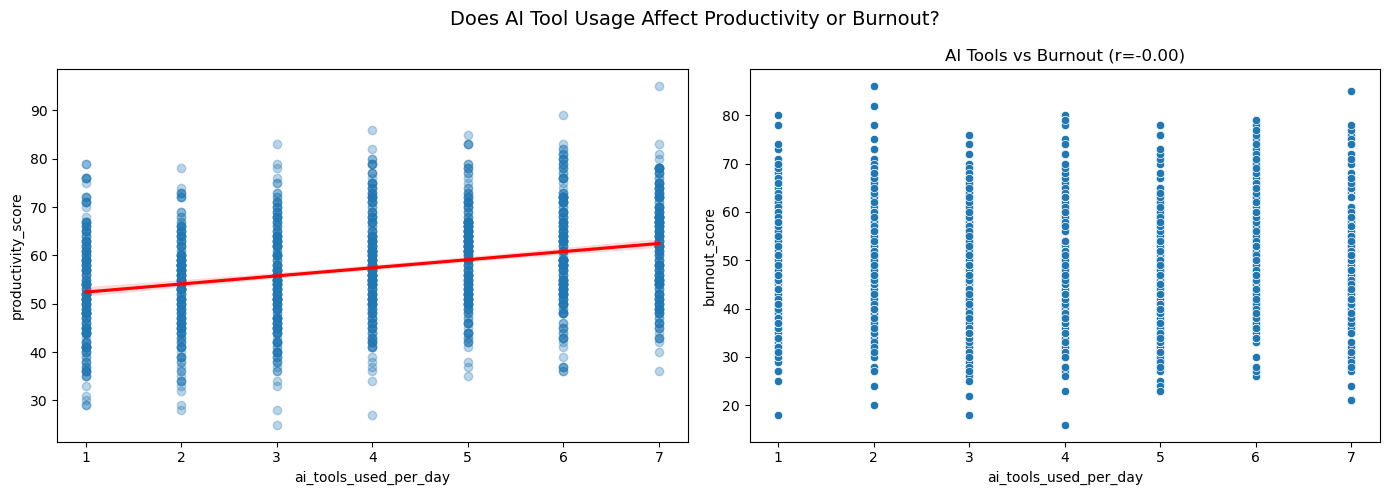

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Replace left scatterplot with:
sns.regplot(data=df, x='ai_tools_used_per_day', y='productivity_score', 
            ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

sns.scatterplot(data=df, x='ai_tools_used_per_day', y='burnout_score', ax=axes[1])
axes[1].set_title(f'AI Tools vs Burnout (r={corr_burnout:.2f})')

plt.suptitle('Does AI Tool Usage Affect Productivity or Burnout?', fontsize=14)
plt.tight_layout()
plt.show()

In [66]:
tool_impact = df.groupby('ai_tools_used_per_day').agg(
    avg_productivity=('productivity_score', 'mean'),
    avg_burnout=('burnout_score', 'mean')
).round(2)

print(tool_impact)

                       avg_productivity  avg_burnout
ai_tools_used_per_day                               
1                                 52.78        49.89
2                                 53.54        50.90
3                                 54.88        50.49
4                                 58.21        49.15
5                                 59.96        49.14
6                                 60.66        50.78
7                                 61.97        50.22


### 💡 What did we find?

Using more AI tools **does** increase productivity — moderately (r=0.31).
Employees using 6-7 tools daily show noticeably higher productivity 
than those using just 1-2.

But here's the good news — more AI tools do NOT increase burnout (r=-0.00).
The relationship is completely flat.

**The takeaway:**
> "Use more AI tools — you'll be more productive and no more burned out.
> AI tools are a productivity gift, not a mental health cost."

## 5. Do remote workers experience different burnout patterns?

### ⚠️ Important Note on Analysis
Each question in this analysis examines one factor at a time.
In reality, burnout, productivity and fear of AI replacement 
are influenced by multiple variables simultaneously —
including years of experience, salary, company size, and job role.
These findings should be interpreted as patterns and signals,
not definitive causes.

In [70]:
patterns = df.groupby('remote_work_type').agg(
    burnout=('burnout_score', 'mean'),
    satisfaction=('job_satisfaction_1_5', 'mean')
).round(2)
print(patterns)

                  burnout  satisfaction
remote_work_type                       
Fully Remote        50.22          3.30
Hybrid              49.63          3.36
On-site             50.57          3.35


### 💡 What did we find?

Remote work type has virtually no effect on burnout or job satisfaction.

Fully remote, hybrid, and on-site employees all report nearly identical 
burnout scores (49-50) and satisfaction levels (3.3-3.36).

This challenges the common narrative that remote work either 
saves or destroys employee wellbeing.

> *"Where you work doesn't determine how burned out you are.
> Something else is driving burnout — and it's not your location."*

## 6. Do higher salaries protect against burnout?

In [88]:
df['salaries'] = pd.cut(df['salary_usd_k'], bins=[0, 50, 100,150,200 ,300], labels=['0-50K','50-100K','100-150K','150-200K','200+'])
sal_prot= df.groupby('salaries', observed=True).agg(
    avg_burnout = ('burnout_score', 'mean'),
    count= ('salary_usd_k', 'count')
).round(2)
print(sal_prot)

          avg_burnout  count
salaries                    
0-50K           47.24     82
50-100K         50.62    369
100-150K        49.92    392
150-200K        50.73    346
200+            49.54    311


### 💡 What did we find?
Higher salaries do not consistently protect against burnout.
The pattern is irregular — suggesting salary alone is not 
the primary driver of burnout.

Other factors like job responsibility, working hours, and 
pressure that accompany higher salaries likely play a 
bigger role than the paycheck itself.

> *"It's not about how much you earn —
> it's about what you have to give to earn it."*

## 🎯 What I Want to Learn Next
- Linear Regression — to analyze multiple factors simultaneously
  and find what truly drives outcomes like burnout
- Statistics fundamentals — correlation vs causation, p-values

## 7.Which country has the highest attrition risk?

             high_attrition_count
country                          
UK                             12
Australia                      10
Germany                         9
Netherlands                     9
Canada                          8
Singapore                       8
USA                             8
Brazil                          7
France                          7
India                           7


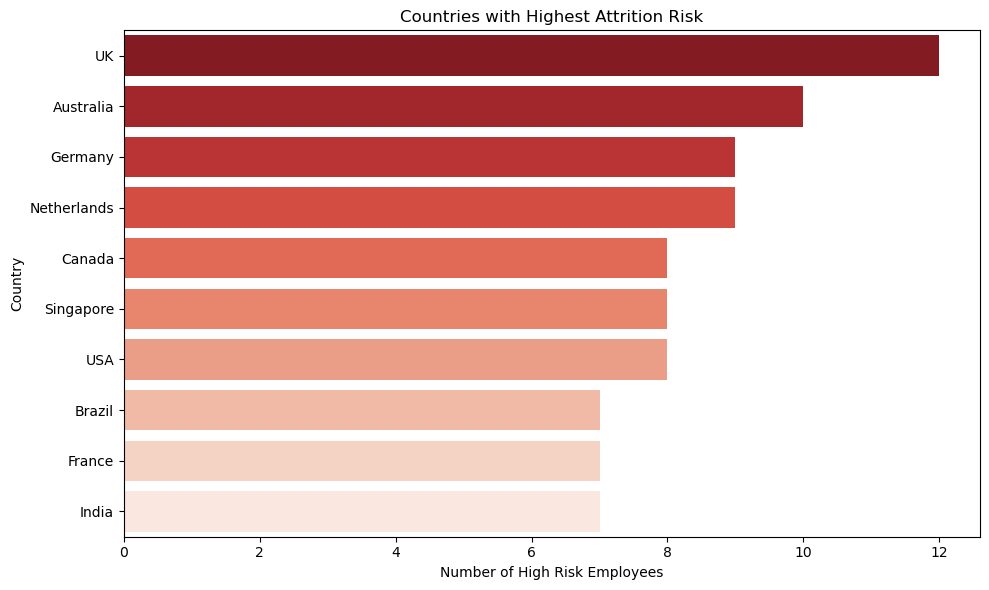

In [87]:
att_by_country = df[df['attrition_risk'] == 'High'] \
                   .groupby('country').agg(
                       high_attrition_count=('attrition_risk', 'count')
                   ).sort_values('high_attrition_count', ascending=False)

print(att_by_country)

plt.figure(figsize=(10, 6))
sns.barplot(data=att_by_country.reset_index(), 
            x='high_attrition_count', 
            y='country',
            hue='country',
            palette='Reds_r',
            legend=False)
plt.title('Countries with Highest Attrition Risk')
plt.xlabel('Number of High Risk Employees')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### 💡 What did we find?
The UK leads with the highest attrition risk (12 high-risk employees),
followed by Australia (10) and Germany & Netherlands (9 each).

Interestingly — India, France and Brazil show the lowest attrition 
risk despite being major tech markets.

> *"Western markets appear to face higher employee retention challenges —
> possibly reflecting more competitive job markets and 
> higher employee expectations."*

## 8.Is there a relationship between burnout and job satisfaction?

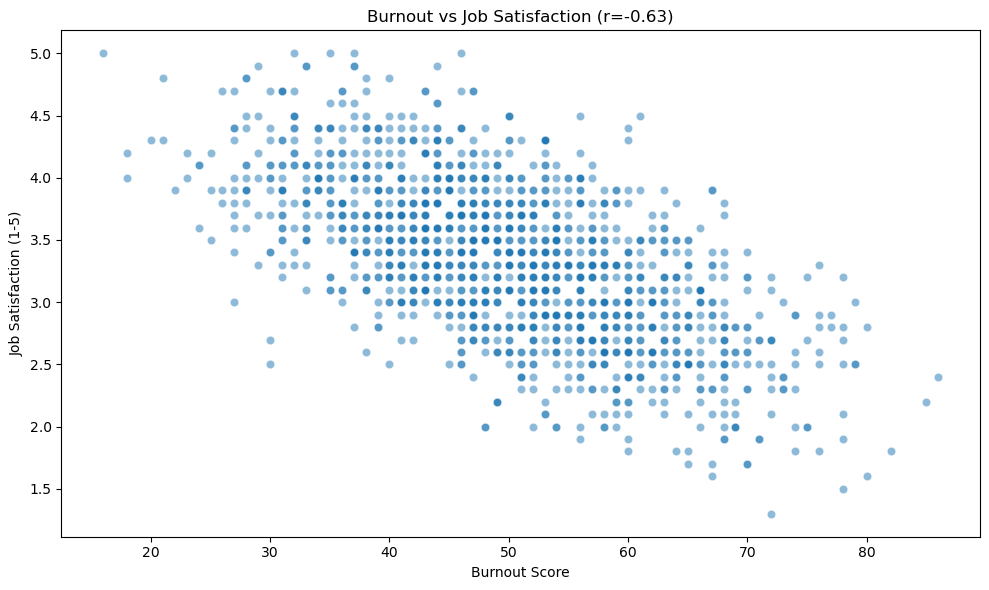

In [90]:
corr_value = df['burnout_score'].corr(df['job_satisfaction_1_5'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='burnout_score', y='job_satisfaction_1_5', alpha=0.5)
plt.title(f'Burnout vs Job Satisfaction (r={corr_value:.2f})')
plt.xlabel('Burnout Score')
plt.ylabel('Job Satisfaction (1-5)')
plt.tight_layout()
plt.show()

### 💡 What did we find?

Strong negative correlation of -0.63 between burnout and satisfaction.

Even in a tech workforce heavily focused on AI tools and automation —
employees who feel like a value added to their work burn out significantly less.

We still don't know exactly what CAUSES burnout.
But we know this: as job satisfaction rises, burnout collapses.

> *"You don't burn out from working hard.
> You burn out from feeling like your work doesn't matter."*

## 9.Is there a sweet spot of AI usage that maximizes productivity without burnout?

In [91]:
df['ai_hours_range'] = pd.cut(df['hours_with_ai_assistance_daily'],
                               bins=[0, 1, 2, 3, 4, 5],
                               labels=['0-1h', '1-2h', '2-3h', '3-4h', '4-5h'])

sweet_spot = df.groupby('ai_hours_range', observed=True).agg(
    avg_productivity=('productivity_score', 'mean'),
    avg_burnout=('burnout_score', 'mean'),
    count=('employee_id', 'count')
).round(2)

print(sweet_spot)

                avg_productivity  avg_burnout  count
ai_hours_range                                      
0-1h                       56.82        45.01    110
1-2h                       57.50        43.02    197
2-3h                       57.19        46.69    197
3-4h                       56.59        48.73    202
4-5h                       57.47        49.42    219


### 💡 What did we find?
No clear sweet spot exists for AI usage and productivity.
Differences across all time ranges are minimal — suggesting 
AI hours alone don't determine how productive you are.

More importantly — this closes a chapter in our burnout investigation:
After testing remote work, salary, education, and AI usage —
none of them meaningfully explain burnout.

Only job satisfaction showed a strong relationship (-0.63).

> *"Burnout is not about how much you work with AI,
> how much you earn, or where you work from.
> It's about whether your work means something to you."*

The burnout question remains open for deeper analysis —
requiring multivariate regression to truly untangle the causes.